## Download mini dataset

In [1]:
import os
from tqdm import tqdm

dataset_dir = "skm-tea/v1-release"
url = "https://huggingface.co/datasets/arjundd/skm-tea-mini/resolve/main/v1-release"
force_download = False


if force_download:
    !rm -rf $dataset_dir

if not os.path.isdir(dataset_dir):
    os.makedirs(dataset_dir)
    for fname in ["all_metadata.csv", "annotations/v1.0.0/train.json", "annotations/v1.0.0/val.json", "annotations/v1.0.0/test.json"]:
        out = f"{dataset_dir}/{fname}"
        os.makedirs(os.path.dirname(out), exist_ok=True)
        !wget -q $url/$fname -O $out
  

    for fname in tqdm(["dicoms", "files_recon_calib-24", "image_files", "segmentation_masks"], disable=False):
        !wget -c $url/"tarball"/$fname".tar.gz" -O - | tar -xz -C $dataset_dir/

!ls

DICOM_Plot.ipynb   MR_project.zip     dicoms
EDA.ipynb          dicom_MTR_001      segmentation_masks
EDA_json           dicom_MTR_005      skm-tea


## Load .h5 Files & Visualize Slices + Segmentation Masks

In [2]:
from pprint import pprint

import numpy as np
import torch
import h5py
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from skimage.color import label2rgb
import pandas as pd
from torch import nn
import torch.nn.functional as F
import cv2
import json
import csv

%matplotlib inline

In [4]:
# adapted from meddlr
def one_hot_to_categorical(x, channel_dim: int = 1, background=False):
    """Converts one-hot encoded predictions to categorical predictions.

    Args:
        x (torch.Tensor | np.ndarray): One-hot encoded predictions.
        channel_dim (int, optional): Channel dimension.
            Defaults to ``1`` (i.e. ``(B,C,...)``).
        background (bool, optional): If ``True``, assumes index 0 in the
            channel dimension is the background.

    Returns:
        torch.Tensor | np.ndarray: Categorical array or tensor. If ``background=False``,
        the output will be 1-indexed such that ``0`` corresponds to the background.
    """
    is_ndarray = isinstance(x, np.ndarray)
    if is_ndarray:
        x = torch.as_tensor(x)

    if background is not None and background is not False:
        out = torch.argmax(x, channel_dim)
    else:
        out = torch.argmax(x.type(torch.long), dim=channel_dim) + 1
        out = torch.where(x.sum(channel_dim) == 0, torch.tensor([0], device=x.device), out)

    if is_ndarray:
        out = out.numpy()
    return out


In [5]:
with h5py.File("skm-tea/v1-release/image_files/MTR_030.h5", "r") as f:
    # Print all root level object names (aka keys) 
    # these can be group or dataset names 
    print("Keys: %s" % f.keys())
    
    # get first object name/key; may or may NOT be a group
    a_group_key = list(f.keys())[0]
    # get the object type for a_group_key: usually group or dataset
    print(type(f[a_group_key])) 
    
    # If a_group_key is a group name, 
    # this gets the object names in the group and returns as a list
    data = list(f[a_group_key])

    # If a_group_key is a dataset name, 
    # this gets the dataset values and returns as a list
    data = list(f[a_group_key])
    # preferred methods to get dataset values:
    ds_obj = f[a_group_key]      # returns as a h5py dataset object
    ds_arr = f[a_group_key][()]  # returns as a numpy array

Keys: <KeysViewHDF5 ['echo1', 'echo2', 'seg', 'stats']>
<class 'h5py._hl.dataset.Dataset'>


In [517]:
sl = 100 # slice # to view

with h5py.File("skm-tea/v1-release/image_files/MTR_184.h5", "r") as f:
    echo1 = f["echo1"][:, :, sl]
    echo2 = f["echo2"][:, :, sl]
    seg = f["seg"][:, :, sl, :]

In [518]:
seg.shape

(512, 512, 6)

In [519]:
segmentation = one_hot_to_categorical(seg, channel_dim=-1)
segmentation.shape

(512, 512)

In [520]:
segmentation.nonzero() # index positions

(array([148, 148, 148, ..., 310, 310, 310]),
 array([355, 356, 357, ..., 199, 200, 201]))

In [521]:
# check segmentation class
segmentation[148, 355]

2

In [522]:
segmentation[310, 200]

5

In [523]:
seg_colorized = label2rgb(segmentation, bg_label=0, bg_color=None)
seg_colorized.shape

(512, 512, 3)

In [524]:
# scale img to [0, 1]
echo1_scaled = cv2.normalize(echo1, None, 0, 255, cv2.NORM_MINMAX) / 255
echo2_scaled = cv2.normalize(echo2, None, 0, 255, cv2.NORM_MINMAX) / 255


(-0.5, 511.5, 511.5, -0.5)

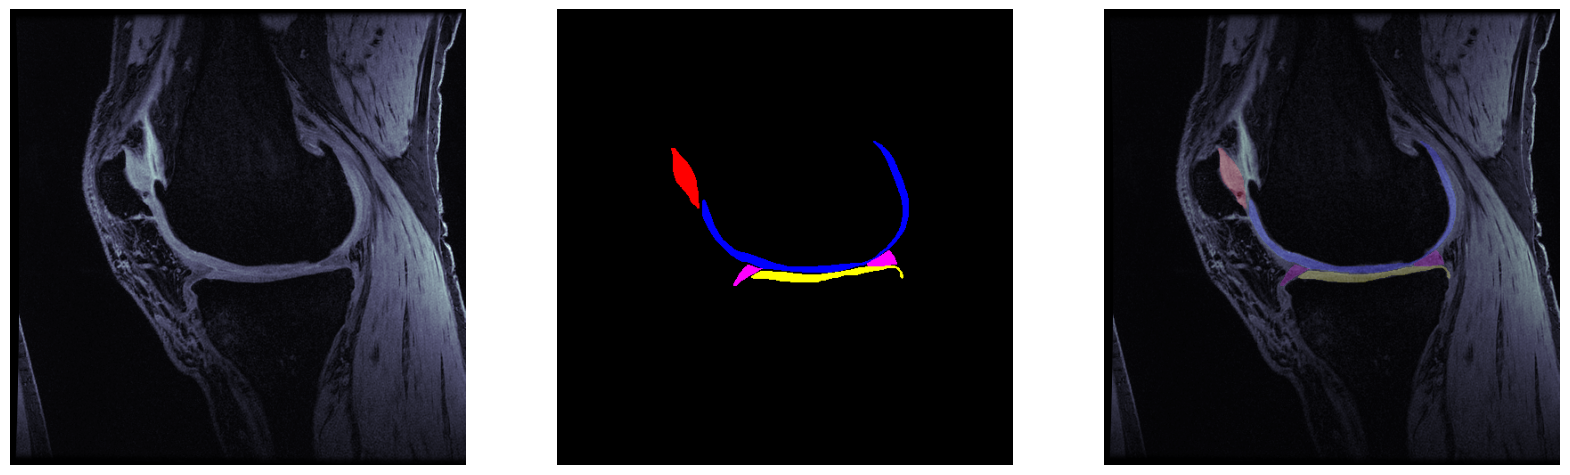

In [525]:
fig, axes = plt.subplots(1, 3, figsize = (20, 20))
axes[0].imshow(echo1_scaled, cmap = plt.cm.bone)
axes[1].imshow(seg_colorized)
axes[2].imshow(echo1_scaled, cmap = plt.cm.bone)
axes[2].imshow(seg_colorized, alpha = 0.2)

axes[0].axis("off")
axes[1].axis("off")
axes[2].axis("off")

## Merge annotation files

In [38]:
f_json = open("skm-tea/v1-release/annotations/v1.0.0/val.json")
dat = json.load(f_json)

In [39]:
categories = pd.json_normalize(dat["categories"])
categories

,supercategory,supercategory_id,id,name
0,Meniscal Tear,1,1,Meniscal Tear (Myxoid)
1,Meniscal Tear,1,2,Meniscal Tear (Horizontal)
2,Meniscal Tear,1,3,Meniscal Tear (Radial)
3,Meniscal Tear,1,4,Meniscal Tear (Vertical/Longitudinal)
4,Meniscal Tear,1,5,Meniscal Tear (Oblique)
5,Meniscal Tear,1,6,Meniscal Tear (Complex)
6,Meniscal Tear,1,7,Meniscal Tear (Flap)
7,Meniscal Tear,1,8,Meniscal Tear (Extrusion)
8,Ligament Tear,2,9,Ligament Tear (Low-Grade Sprain)
9,Ligament Tear,2,10,Ligament Tear (Moderate Grade Sprain or Mucoid...


In [14]:
cat_dict = dict(zip(categories.id, categories.name))
cat_id_to_supercat_id = dict(zip(categories.id, categories.supercategory_id))
supercat_dict = dict(zip(categories.supercategory_id, categories.supercategory))

In [15]:
annotations = pd.json_normalize(dat["annotations"])
annotations

,id,image_id,category_id,tissue_id,bbox,confidence,labeler
0,1,1,6,1,"[256.0, 360.0, 88.0, 48.0, 39.0, 50.0]",2.0,2
1,2,1,8,1,"[283.0, 216.0, 112.0, 42.0, 153.0, 28.0]",3.0,2
2,3,1,6,1,"[252.0, 350.0, 30.0, 46.0, 41.0, 29.0]",3.0,2
3,4,1,10,2,"[188.0, 239.0, 58.0, 110.0, 119.0, 27.0]",3.0,2
4,5,1,14,4,"[260.0, 235.0, 100.0, 44.0, 141.0, 37.0]",3.0,2
5,6,1,15,6,"[297.0, 252.0, 98.0, 13.0, 101.0, 32.0]",3.0,2
6,7,1,13,4,"[176.0, 250.0, 29.0, 120.0, 138.0, 28.0]",2.0,2
7,8,1,13,5,"[165.0, 130.0, 58.0, 61.0, 37.0, 50.0]",3.0,2
8,9,1,14,4,"[170.0, 164.0, 79.0, 115.0, 54.0, 30.0]",3.0,2
9,10,1,16,-1,"[8.0, 122.0, 7.0, 257.0, 184.0, 121.0]",4.0,2


In [16]:
annotations["category"] = annotations["category_id"].map(cat_dict)
annotations["supercat_id"] = annotations["category_id"].map(cat_id_to_supercat_id) 
annotations["supercategory"] = annotations["supercat_id"].map(supercat_dict) 
annotations

,id,image_id,category_id,tissue_id,bbox,confidence,labeler,category,supercat_id,supercategory
0,1,1,6,1,"[256.0, 360.0, 88.0, 48.0, 39.0, 50.0]",2.0,2,Meniscal Tear (Complex),1,Meniscal Tear
1,2,1,8,1,"[283.0, 216.0, 112.0, 42.0, 153.0, 28.0]",3.0,2,Meniscal Tear (Extrusion),1,Meniscal Tear
2,3,1,6,1,"[252.0, 350.0, 30.0, 46.0, 41.0, 29.0]",3.0,2,Meniscal Tear (Complex),1,Meniscal Tear
3,4,1,10,2,"[188.0, 239.0, 58.0, 110.0, 119.0, 27.0]",3.0,2,Ligament Tear (Moderate Grade Sprain or Mucoid...,2,Ligament Tear
4,5,1,14,4,"[260.0, 235.0, 100.0, 44.0, 141.0, 37.0]",3.0,2,Cartilage Lesion (2B),3,Cartilage Lesion
5,6,1,15,6,"[297.0, 252.0, 98.0, 13.0, 101.0, 32.0]",3.0,2,Cartilage Lesion (3),3,Cartilage Lesion
6,7,1,13,4,"[176.0, 250.0, 29.0, 120.0, 138.0, 28.0]",2.0,2,Cartilage Lesion (2A),3,Cartilage Lesion
7,8,1,13,5,"[165.0, 130.0, 58.0, 61.0, 37.0, 50.0]",3.0,2,Cartilage Lesion (2A),3,Cartilage Lesion
8,9,1,14,4,"[170.0, 164.0, 79.0, 115.0, 54.0, 30.0]",3.0,2,Cartilage Lesion (2B),3,Cartilage Lesion
9,10,1,16,-1,"[8.0, 122.0, 7.0, 257.0, 184.0, 121.0]",4.0,2,Effusion,4,Effusion


## 3D-bbox to 2D-bbox

### 3D-bbox Format [top left x, top left y, top left z, delta x, delta y, delta z]
### Check [top left y, top left x, delta y, delta x] on scans

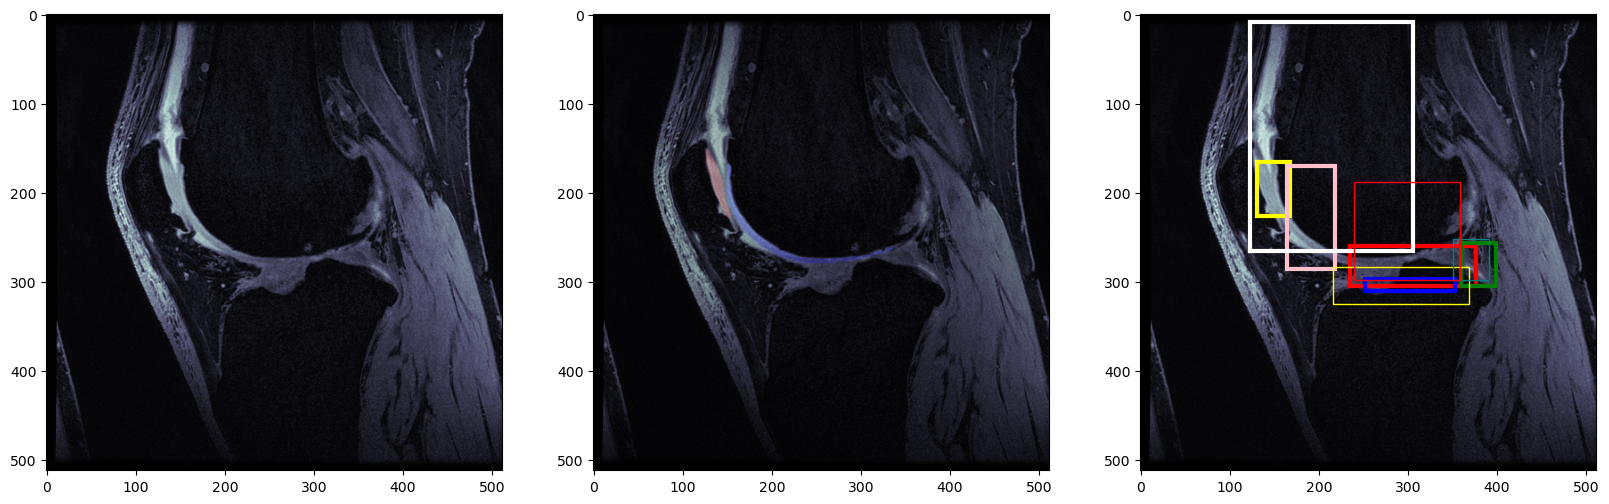

In [157]:
fig, axes = plt.subplots(1, 3, figsize = (20, 20))
axes[0].imshow(echo1_scaled, cmap = plt.cm.bone)
axes[1].imshow(echo1_scaled, cmap = plt.cm.bone)
axes[1].imshow(seg_colorized, alpha = 0.2)
axes[2].imshow(echo1_scaled, cmap = plt.cm.bone)
rec1 = Rectangle((235.0, 260.0), 141, 44, color="red", fill=False)
axes[2].add_patch(rec1)
rec2 = Rectangle((252.0, 297.0), 101, 13, color="blue", fill=False)
axes[2].add_patch(rec2)
rec3 = Rectangle((130.0, 165.0), 37, 61, color="yellow", fill=False)
axes[2].add_patch(rec3)
rec4 = Rectangle((164.0, 170.0), 54, 115, color="pink", fill=False)
axes[2].add_patch(rec4)
rec5 = Rectangle((122.0, 8.0), 184, 257, color="white", fill=False)
axes[2].add_patch(rec5)
rec6 = Rectangle((360.0, 256.0), 39, 48, color="green", fill=False)
axes[2].add_patch(rec6)
rec7 = Rectangle((216.0, 283.0), 153, 42, color="yellow", fill=False)
axes[2].add_patch(rec7)
rec8 = Rectangle((350.0, 252.0), 41, 46, color="teal", fill=False)
axes[2].add_patch(rec8)
rec9 = Rectangle((239.0, 188.0), 119, 110, color="red", fill=False)
axes[2].add_patch(rec9)

rec1.set_linewidth(3)
rec2.set_linewidth(3)
rec3.set_linewidth(3)
rec4.set_linewidth(3)
rec5.set_linewidth(3)
rec6.set_linewidth(3)

### Test converting 3D-bbox into 2D-bbox with a subset

In [330]:
test_annotation = annotations.loc[annotations["id"] <= 2]
test_annotation

,id,image_id,category_id,tissue_id,bbox,confidence,labeler,category,supercat_id,supercategory
0,1,1,6,1,"[256.0, 360.0, 88.0, 48.0, 39.0, 50.0]",2.0,2,Meniscal Tear (Complex),1,Meniscal Tear
1,2,1,8,1,"[283.0, 216.0, 112.0, 42.0, 153.0, 28.0]",3.0,2,Meniscal Tear (Extrusion),1,Meniscal Tear


In [332]:
test = pd.DataFrame()
test

""


In [333]:
for ind in test_annotation.index:
    dict_row = test_annotation.iloc[ind].to_dict()
    for i in range(int(dict_row["bbox"][2]), (int(dict_row["bbox"][2]) + int(dict_row["bbox"][5]))):
        dict_row["sl"] = i
        dict_row["2d_bbox"] = [(dict_row["bbox"][1], dict_row["bbox"][0]), dict_row["bbox"][4], dict_row["bbox"][3]]
        test = test.append(dict_row, ignore_index=True)

/var/folders/x3/s0tpfx6124z6rc3b976f77j00000gn/T/ipykernel_13148/2120281847.py:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  test = test.append(dict_row, ignore_index=True)
/var/folders/x3/s0tpfx6124z6rc3b976f77j00000gn/T/ipykernel_13148/2120281847.py:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  test = test.append(dict_row, ignore_index=True)
/var/folders/x3/s0tpfx6124z6rc3b976f77j00000gn/T/ipykernel_13148/2120281847.py:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  test = test.append(dict_row, ignore_index=True)
/var/folders/x3/s0tpfx6124z6rc3b976f77j00000gn/T/ipykernel_13148/2120281847.py:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat

In [526]:
test

,id,image_id,category_id,tissue_id,bbox,confidence,labeler,category,supercat_id,supercategory,sl,2d_bbox
0,1,1,6,1,"[256.0, 360.0, 88.0, 48.0, 39.0, 50.0]",2.0,2,Meniscal Tear (Complex),1,Meniscal Tear,88,"[(360.0, 256.0), 39.0, 48.0]"
1,1,1,6,1,"[256.0, 360.0, 88.0, 48.0, 39.0, 50.0]",2.0,2,Meniscal Tear (Complex),1,Meniscal Tear,89,"[(360.0, 256.0), 39.0, 48.0]"
2,1,1,6,1,"[256.0, 360.0, 88.0, 48.0, 39.0, 50.0]",2.0,2,Meniscal Tear (Complex),1,Meniscal Tear,90,"[(360.0, 256.0), 39.0, 48.0]"
3,1,1,6,1,"[256.0, 360.0, 88.0, 48.0, 39.0, 50.0]",2.0,2,Meniscal Tear (Complex),1,Meniscal Tear,91,"[(360.0, 256.0), 39.0, 48.0]"
4,1,1,6,1,"[256.0, 360.0, 88.0, 48.0, 39.0, 50.0]",2.0,2,Meniscal Tear (Complex),1,Meniscal Tear,92,"[(360.0, 256.0), 39.0, 48.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...
73,2,1,8,1,"[283.0, 216.0, 112.0, 42.0, 153.0, 28.0]",3.0,2,Meniscal Tear (Extrusion),1,Meniscal Tear,135,"[(216.0, 283.0), 153.0, 42.0]"
74,2,1,8,1,"[283.0, 216.0, 112.0, 42.0, 153.0, 28.0]",3.0,2,Meniscal Tear (Extrusion),1,Meniscal Tear,136,"[(216.0, 283.0), 153.0, 42.0]"
75,2,1,8,1,"[283.0, 216.0, 112.0, 42.0, 153.0, 28.0]",3.0,2,Meniscal Tear (Extrusion),1,Meniscal Tear,137,"[(216.0, 283.0), 153.0, 42.0]"
76,2,1,8,1,"[283.0, 216.0, 112.0, 42.0, 153.0, 28.0]",3.0,2,Meniscal Tear (Extrusion),1,Meniscal Tear,138,"[(216.0, 283.0), 153.0, 42.0]"


### converting 3D-bbox into 2D-bbox

In [337]:
df = pd.DataFrame()

for ind in annotations.index:
    dict_row = annotations.iloc[ind].to_dict()
    for i in range(int(dict_row["bbox"][2]), (int(dict_row["bbox"][2]) + int(dict_row["bbox"][5]))):
        dict_row["sl"] = i
        dict_row["2d_bbox"] = [(dict_row["bbox"][1], dict_row["bbox"][0]), dict_row["bbox"][4], dict_row["bbox"][3]]
        df = df.append(dict_row, ignore_index=True)
        

/var/folders/x3/s0tpfx6124z6rc3b976f77j00000gn/T/ipykernel_13148/1083229335.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(dict_row, ignore_index=True)
/var/folders/x3/s0tpfx6124z6rc3b976f77j00000gn/T/ipykernel_13148/1083229335.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(dict_row, ignore_index=True)
/var/folders/x3/s0tpfx6124z6rc3b976f77j00000gn/T/ipykernel_13148/1083229335.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(dict_row, ignore_index=True)
/var/folders/x3/s0tpfx6124z6rc3b976f77j00000gn/T/ipykernel_13148/1083229335.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  

/var/folders/x3/s0tpfx6124z6rc3b976f77j00000gn/T/ipykernel_13148/1083229335.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(dict_row, ignore_index=True)
/var/folders/x3/s0tpfx6124z6rc3b976f77j00000gn/T/ipykernel_13148/1083229335.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(dict_row, ignore_index=True)
/var/folders/x3/s0tpfx6124z6rc3b976f77j00000gn/T/ipykernel_13148/1083229335.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(dict_row, ignore_index=True)
/var/folders/x3/s0tpfx6124z6rc3b976f77j00000gn/T/ipykernel_13148/1083229335.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  

/var/folders/x3/s0tpfx6124z6rc3b976f77j00000gn/T/ipykernel_13148/1083229335.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(dict_row, ignore_index=True)
/var/folders/x3/s0tpfx6124z6rc3b976f77j00000gn/T/ipykernel_13148/1083229335.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(dict_row, ignore_index=True)
/var/folders/x3/s0tpfx6124z6rc3b976f77j00000gn/T/ipykernel_13148/1083229335.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(dict_row, ignore_index=True)
/var/folders/x3/s0tpfx6124z6rc3b976f77j00000gn/T/ipykernel_13148/1083229335.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  

In [338]:
df

,id,image_id,category_id,tissue_id,bbox,confidence,labeler,category,supercat_id,supercategory,sl,2d_bbox
0,1,1,6,1,"[256.0, 360.0, 88.0, 48.0, 39.0, 50.0]",2.0,2,Meniscal Tear (Complex),1,Meniscal Tear,88,"[(360.0, 256.0), 39.0, 48.0]"
1,1,1,6,1,"[256.0, 360.0, 88.0, 48.0, 39.0, 50.0]",2.0,2,Meniscal Tear (Complex),1,Meniscal Tear,89,"[(360.0, 256.0), 39.0, 48.0]"
2,1,1,6,1,"[256.0, 360.0, 88.0, 48.0, 39.0, 50.0]",2.0,2,Meniscal Tear (Complex),1,Meniscal Tear,90,"[(360.0, 256.0), 39.0, 48.0]"
3,1,1,6,1,"[256.0, 360.0, 88.0, 48.0, 39.0, 50.0]",2.0,2,Meniscal Tear (Complex),1,Meniscal Tear,91,"[(360.0, 256.0), 39.0, 48.0]"
4,1,1,6,1,"[256.0, 360.0, 88.0, 48.0, 39.0, 50.0]",2.0,2,Meniscal Tear (Complex),1,Meniscal Tear,92,"[(360.0, 256.0), 39.0, 48.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...
427,10,1,16,-1,"[8.0, 122.0, 7.0, 257.0, 184.0, 121.0]",4.0,2,Effusion,4,Effusion,123,"[(122.0, 8.0), 184.0, 257.0]"
428,10,1,16,-1,"[8.0, 122.0, 7.0, 257.0, 184.0, 121.0]",4.0,2,Effusion,4,Effusion,124,"[(122.0, 8.0), 184.0, 257.0]"
429,10,1,16,-1,"[8.0, 122.0, 7.0, 257.0, 184.0, 121.0]",4.0,2,Effusion,4,Effusion,125,"[(122.0, 8.0), 184.0, 257.0]"
430,10,1,16,-1,"[8.0, 122.0, 7.0, 257.0, 184.0, 121.0]",4.0,2,Effusion,4,Effusion,126,"[(122.0, 8.0), 184.0, 257.0]"


### check annotation for a particular slice and plot

In [472]:
sl_100_test = df.loc[df["sl"] == 100]
sl_100_test

,id,image_id,category_id,tissue_id,bbox,confidence,labeler,category,supercat_id,supercategory,sl,2d_bbox
12,1,1,6,1,"[256.0, 360.0, 88.0, 48.0, 39.0, 50.0]",2.0,2,Meniscal Tear (Complex),1,Meniscal Tear,100,"[(360.0, 256.0), 39.0, 48.0]"
134,5,1,14,4,"[260.0, 235.0, 100.0, 44.0, 141.0, 37.0]",3.0,2,Cartilage Lesion (2B),3,Cartilage Lesion,100,"[(235.0, 260.0), 141.0, 44.0]"
173,6,1,15,6,"[297.0, 252.0, 98.0, 13.0, 101.0, 32.0]",3.0,2,Cartilage Lesion (3),3,Cartilage Lesion,100,"[(252.0, 297.0), 101.0, 13.0]"
273,8,1,13,5,"[165.0, 130.0, 58.0, 61.0, 37.0, 50.0]",3.0,2,Cartilage Lesion (2A),3,Cartilage Lesion,100,"[(130.0, 165.0), 37.0, 61.0]"
302,9,1,14,4,"[170.0, 164.0, 79.0, 115.0, 54.0, 30.0]",3.0,2,Cartilage Lesion (2B),3,Cartilage Lesion,100,"[(164.0, 170.0), 54.0, 115.0]"
404,10,1,16,-1,"[8.0, 122.0, 7.0, 257.0, 184.0, 121.0]",4.0,2,Effusion,4,Effusion,100,"[(122.0, 8.0), 184.0, 257.0]"


In [473]:
sl = 100

with h5py.File("skm-tea/v1-release/image_files/MTR_184.h5", "r") as f:
    echo1 = f["echo1"][:, :, sl]
    echo2 = f["echo2"][:, :, sl]
    seg = f["seg"][:, :, sl, :]

segmentation = one_hot_to_categorical(seg, channel_dim=-1)
seg_colorized = label2rgb(segmentation, bg_label=0, bg_color=None)
echo1_scaled = cv2.normalize(echo1, None, 0, 255, cv2.NORM_MINMAX) / 255

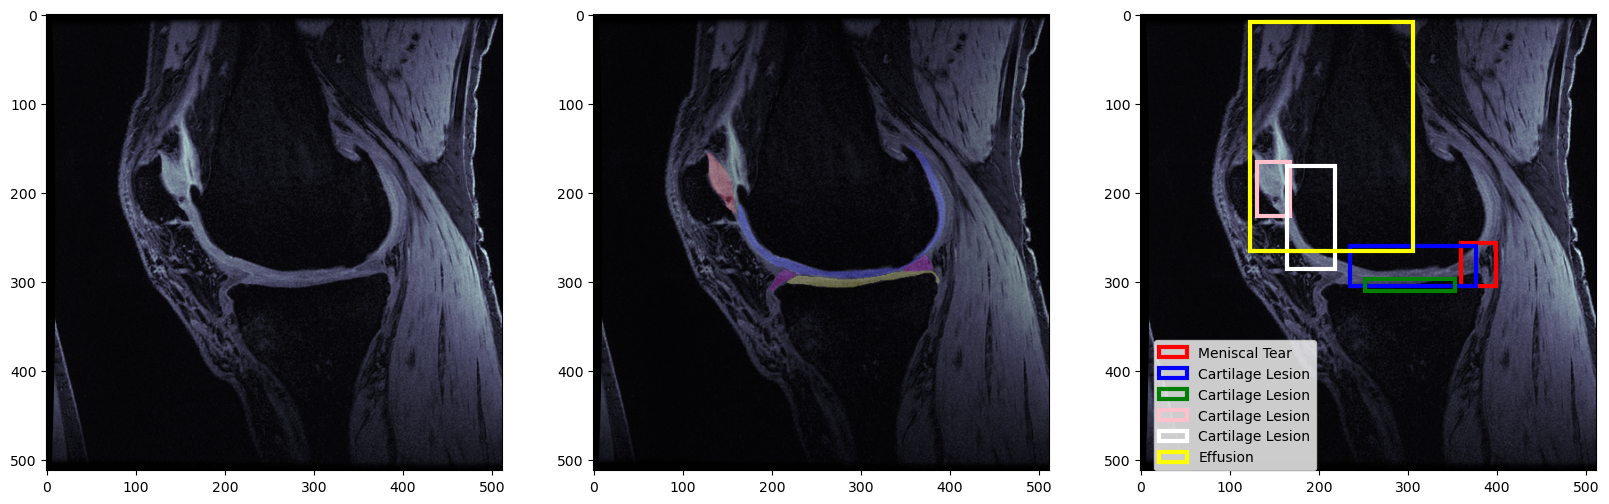

In [476]:
fig, axes = plt.subplots(1, 3, figsize = (20, 20))
axes[0].imshow(echo1_scaled, cmap = plt.cm.bone)
axes[1].imshow(echo1_scaled, cmap = plt.cm.bone)
axes[1].imshow(seg_colorized, alpha = 0.2)
axes[2].imshow(echo1_scaled, cmap = plt.cm.bone)

colors = ["red", "blue", "green", "pink", "white", "yellow", "teal"]

for i in range(sl_100_test.shape[0]):
    rec = Rectangle(sl_100_test.iloc[i]["2d_bbox"][0], 
                    sl_100_test.iloc[i]["2d_bbox"][1], 
                    sl_100_test.iloc[i]["2d_bbox"][2],
                    color = colors[i], fill = False,
                    label = sl_100_test.iloc[i]["supercategory"])
    axes[2].add_patch(rec)
    rec.set_linewidth(3)
    axes[2].legend(bbox_to_anchor = (0.4, 0.3))

(-0.5, 511.5, 511.5, -0.5)

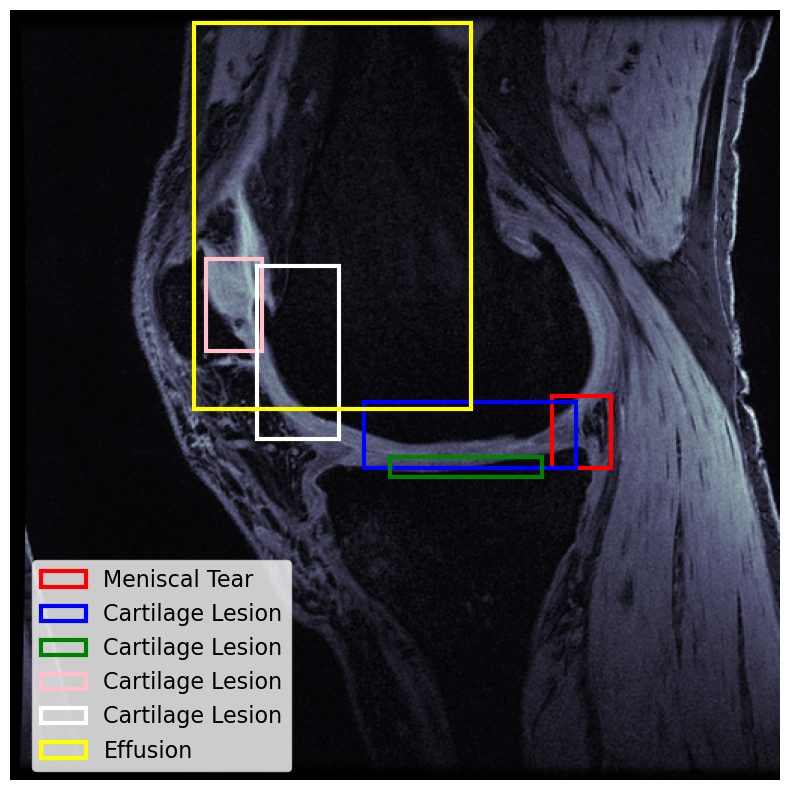

In [486]:
fig, axes = plt.subplots(figsize = (10, 10))
axes.imshow(echo1_scaled, cmap = plt.cm.bone)

colors = ["red", "blue", "green", "pink", "white", "yellow", "teal"]

for i in range(sl_100_test.shape[0]):
    rec = Rectangle(sl_100_test.iloc[i]["2d_bbox"][0], 
                    sl_100_test.iloc[i]["2d_bbox"][1], 
                    sl_100_test.iloc[i]["2d_bbox"][2],
                    color = colors[i], fill = False,
                    label = sl_100_test.iloc[i]["supercategory"])
    axes.add_patch(rec)
    rec.set_linewidth(3)
    axes.legend(bbox_to_anchor = (0.38, 0.3),
                fontsize = 16)


axes.axis("off")

## Image Intensity Normalization

https://onlinelibrary.wiley.com/doi/abs/10.1002/%28SICI%291522-2594%28199912%2942%3A6%3C1072%3A%3AAID-MRM11%3E3.0.CO%3B2-M?sid=nlm%3Apubmed

https://github.com/jcreinhold/intensity-normalization

In [443]:
!pip install intensity-normalization


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.8/50.8 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 22.0 MB/s eta 0:00:00m eta 0:00:010:01:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 994.0/994.0 kB 46.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for scikit-fuzzy: filename=scikit_fuzzy-0.4.2-py3-none-any.whl size=894075 sha256=0b3c1c5baa96ce0cdcd22724151756e67579ac8793ceb43106a79f9c14422898
  Stored in directory: /Users/beijingwu/Library/Caches/pip/wheels/32/2c/a1/a90a7d7dd8448ec029f298a61f3490275e99b17aa348be675c
Successfully built scikit-fuzzy
  Attempting uninstall: nibabel
    Found existing installation: nibabel 5.1.0
    Uninstalling nibabel-5.1.0:
      Successfully uninstalled nibabel-5.1.0


In [445]:
from intensity_normalization.normalize.nyul import NyulNormalize

In [446]:
nyul_normalizer = NyulNormalize()

In [448]:
echo1_list = []
with h5py.File("skm-tea/v1-release/image_files/MTR_184.h5", "r") as f:
    echo1_all = f["echo1"][:, :, :]

for i in range(echo1_all.shape[2]):
    echo1_list.append(echo1_all[:, :, i])

nyul_normalizer.fit(echo1_list)
normalized = [nyul_normalizer(image) for image in echo1_list]
nyul_normalizer.save_standard_histogram("standard_histogram.npy")


In [449]:
new_echo1_list = []

with h5py.File("skm-tea/v1-release/image_files/MTR_201.h5", "r") as f:
    new_echo1_all = f["echo1"][:, :, :]

for i in range(echo1_all.shape[2]):
    new_echo1_list.append(new_echo1_all[:, :, i])
    
new_normalized = [nyul_normalizer(image) for image in new_echo1_list]


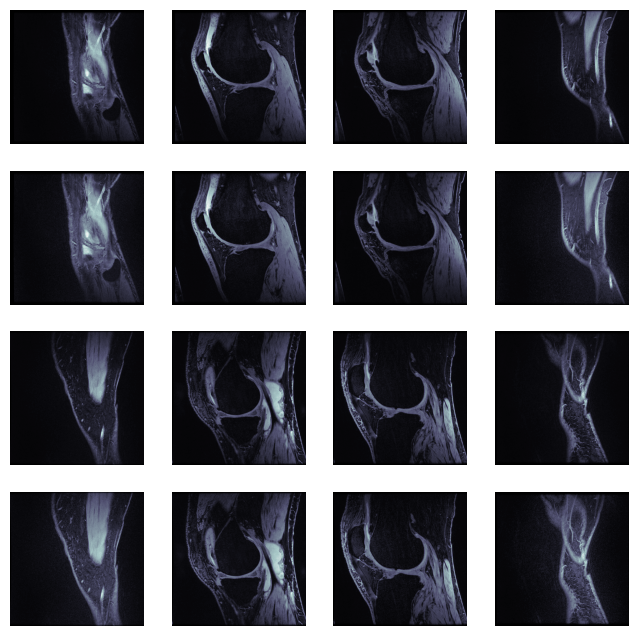

In [492]:
slices = [10, 50, 100, 150]
fig, axes = plt.subplots(4, 4, figsize = (8, 8))
for i in range(len(slices)):
    axes[0][i].imshow(echo1_list[slices[i]], cmap = plt.cm.bone)
    axes[0][i].axis("off")
    axes[1][i].imshow(normalized[slices[i]], cmap = plt.cm.bone)
    axes[1][i].axis("off")
    axes[2][i].imshow(new_echo1_list[slices[i]], cmap = plt.cm.bone)
    axes[2][i].axis("off")
    axes[3][i].imshow(new_normalized[slices[i]], cmap = plt.cm.bone)
    axes[3][i].axis("off")
#axes[0][0].set_title("MTR_184 echo1 original")
#axes[1][0].set_title("MTR_184 echo1 normalized")
#axes[2][0].set_title("MTR_201 echo1 original")
#axes[3][0].set_title("MTR_201 echo1 normalized")

In [451]:
plt.hist(img.ravel(),256,[0,256]); plt.show()


5

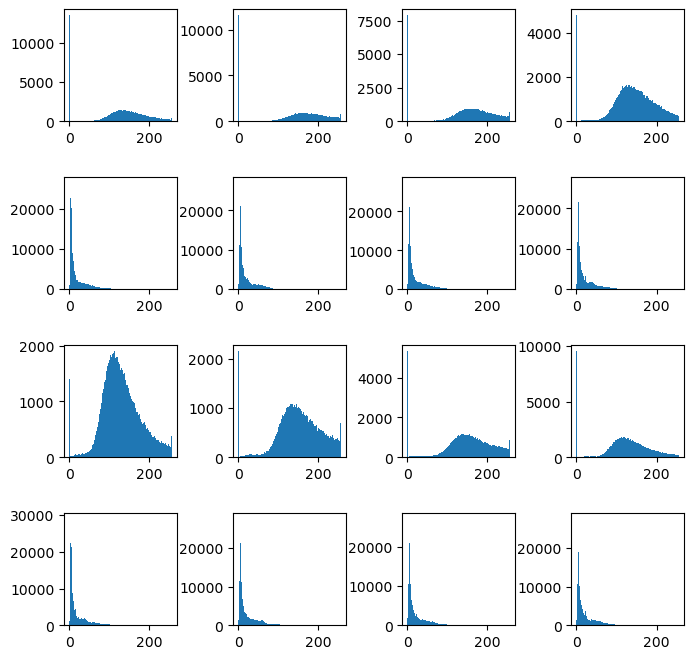

In [501]:
fig, axes = plt.subplots(4, 4, figsize = (8, 8))
plt.subplots_adjust(wspace=.5, hspace=.5)

for i in range(len(slices)):
    axes[0][i].hist(echo1_list[slices[i]].ravel(), 256, [0, 256])
    axes[1][i].hist(normalized[slices[i]].ravel(), 256, [0, 256])
    axes[2][i].hist(new_echo1_list[slices[i]].ravel(), 256, [0, 256])
    axes[3][i].hist(new_normalized[slices[i]].ravel(), 256, [0, 256])

#axes[0][0].set_title("MTR_184 echo1 original")
#axes[1][0].set_title("MTR_184 echo1 normalized")
#axes[2][0].set_title("MTR_201 echo1 original")
#axes[3][0].set_title("MTR_201 echo1 normalized")